# Practical 7: Random Forests, OOB Error, Bagging and Feature Subsampling

## Student Placement Prediction

### Aim
Implement and analyse Random Forests using **training and validation data**, study **OOB error convergence**, compare `max_features`, demonstrate **manual bootstrap bagging**, calculate **permutation importance**, and compare a Random Forest with a single Decision Tree.

### Key points
- **Decision Tree:** one person makes the decision.
- **Bagging:** ask many trees, each trained on a different bootstrap sample.
- **Random Forest:** many trees + bootstrap samples + random feature selection.
- **OOB:** students left out of a tree's bootstrap sample can help evaluate that tree.
- **Permutation importance:** shuffle one feature and see how much model accuracy changes.

### CSV
Use the same 14-row CSV from Practical 1 with columns:

`ID, CGPA, Internships, Backlogs, Aptitude, Placed`

Change `CSV_PATH` below if your filename is different.

> Because this teaching dataset has only 14 students, numerical results are for learning the algorithm and may be unstable.


In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)


In [3]:
# ============================================================
# 2. LOAD IRIS DATASET
# ============================================================

# Change this filename to your actual CSV filename.
from sklearn import datasets

# Load Iris dataset
df = datasets.load_iris()
X = df.data
y = df.target

In [5]:
# ============================================================
# 4. DATA PREPROCESSING
# ============================================================

# Convert Iris data into a DataFrame
data_model = pd.DataFrame(
    df.data,
    columns=df.feature_names
)

# Add target column
data_model["target"] = df.target

# Add readable species names
data_model["species"] = data_model["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

print("Iris Dataset:")
display(data_model.head())

print("\nDataset shape:", data_model.shape)

print("\nClass distribution:")
print(data_model["species"].value_counts())

Iris Dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



Dataset shape: (150, 6)

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [6]:
# ============================================================
# 5. DEFINE X AND y
# ============================================================

X = data_model.drop(columns=["target", "species"])
y = data_model["target"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("Iris species")

print("\nFeature data:")
display(X.head())

print("\nTarget values:")
print(y.head())

Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target:
Iris species

Feature data:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target values:
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


In [10]:
X

,CGPA,Internships,Backlogs,Aptitude
0,8.6,2,0,73
1,9.4,2,0,76
2,9.0,2,0,81
3,5.2,0,1,48
4,5.3,0,1,44
5,5.0,1,0,83
6,6.2,1,1,63
7,6.2,0,1,52
8,8.7,2,1,77
9,7.5,1,0,70


## Step 1 — Training Data and Validation/Test Data

Think of it simply:

- **Training data:** the students the model learns from.
- **Validation/test data:** students kept aside to check performance on unseen data.

We use the same split throughout this practical so the models are compared fairly.


In [10]:
# ============================================================
# 6. TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

Training samples: 105
Validation samples: 45

Training class distribution:
target
1    35
0    35
2    35
Name: count, dtype: int64

Validation class distribution:
target
2    15
1    15
0    15
Name: count, dtype: int64


# Part A — Single Decision Tree Baseline

First build one Decision Tree. This is our baseline.

Then we will build a Random Forest and ask:

**Does many trees work better than one tree?**


In [13]:
# ============================================================
# 7. SINGLE DECISION TREE BASELINE
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_baseline = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

dt_baseline.fit(X_train, y_train)

dt_train_pred = dt_baseline.predict(X_train)
dt_val_pred = dt_baseline.predict(X_val)

dt_train_acc = accuracy_score(y_train, dt_train_pred)
dt_val_acc = accuracy_score(y_val, dt_val_pred)

print("SINGLE DECISION TREE")
print("=" * 50)
print(f"Training Accuracy   : {dt_train_acc:.4f}")
print(f"Validation Accuracy : {dt_val_acc:.4f}")
print(f"Tree Depth          : {dt_baseline.get_depth()}")

SINGLE DECISION TREE
Training Accuracy   : 1.0000
Validation Accuracy : 0.8889
Tree Depth          : 6


# Part B — Random Forest

A Random Forest creates many Decision Trees.

Important parameters:

- `n_estimators` → number of trees.
- `bootstrap=True` → each tree gets a bootstrap sample.
- `oob_score=True` → calculate Out-of-Bag accuracy.
- `max_features` → random feature subsampling at each split.


In [ ]:
# ============================================================
# 8. TRAIN RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    n_estimators=100,
    criterion="entropy",
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_val_pred = rf.predict(X_val)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_val_acc = accuracy_score(y_val, rf_val_pred)

print("RANDOM FOREST")
print("=" * 50)
print(f"Number of Trees     : {rf.n_estimators}")
print(f"Training Accuracy   : {rf_train_acc:.4f}")
print(f"Validation Accuracy : {rf_val_acc:.4f}")
print(f"OOB Accuracy        : {rf.oob_score_:.4f}")
print(f"OOB Error           : {1 - rf.oob_score_:.4f}")


RANDOM FOREST
Number of Trees     : 100
Training Accuracy   : 1.0000
Validation Accuracy : 0.8889
OOB Accuracy        : 0.9524
OOB Error           : 0.0476


In [15]:
len(rf.estimators_)

100

In [16]:
print(rf.estimators_[0])

DecisionTreeClassifier(criterion='entropy', max_features='sqrt',
                       random_state=1608637542)


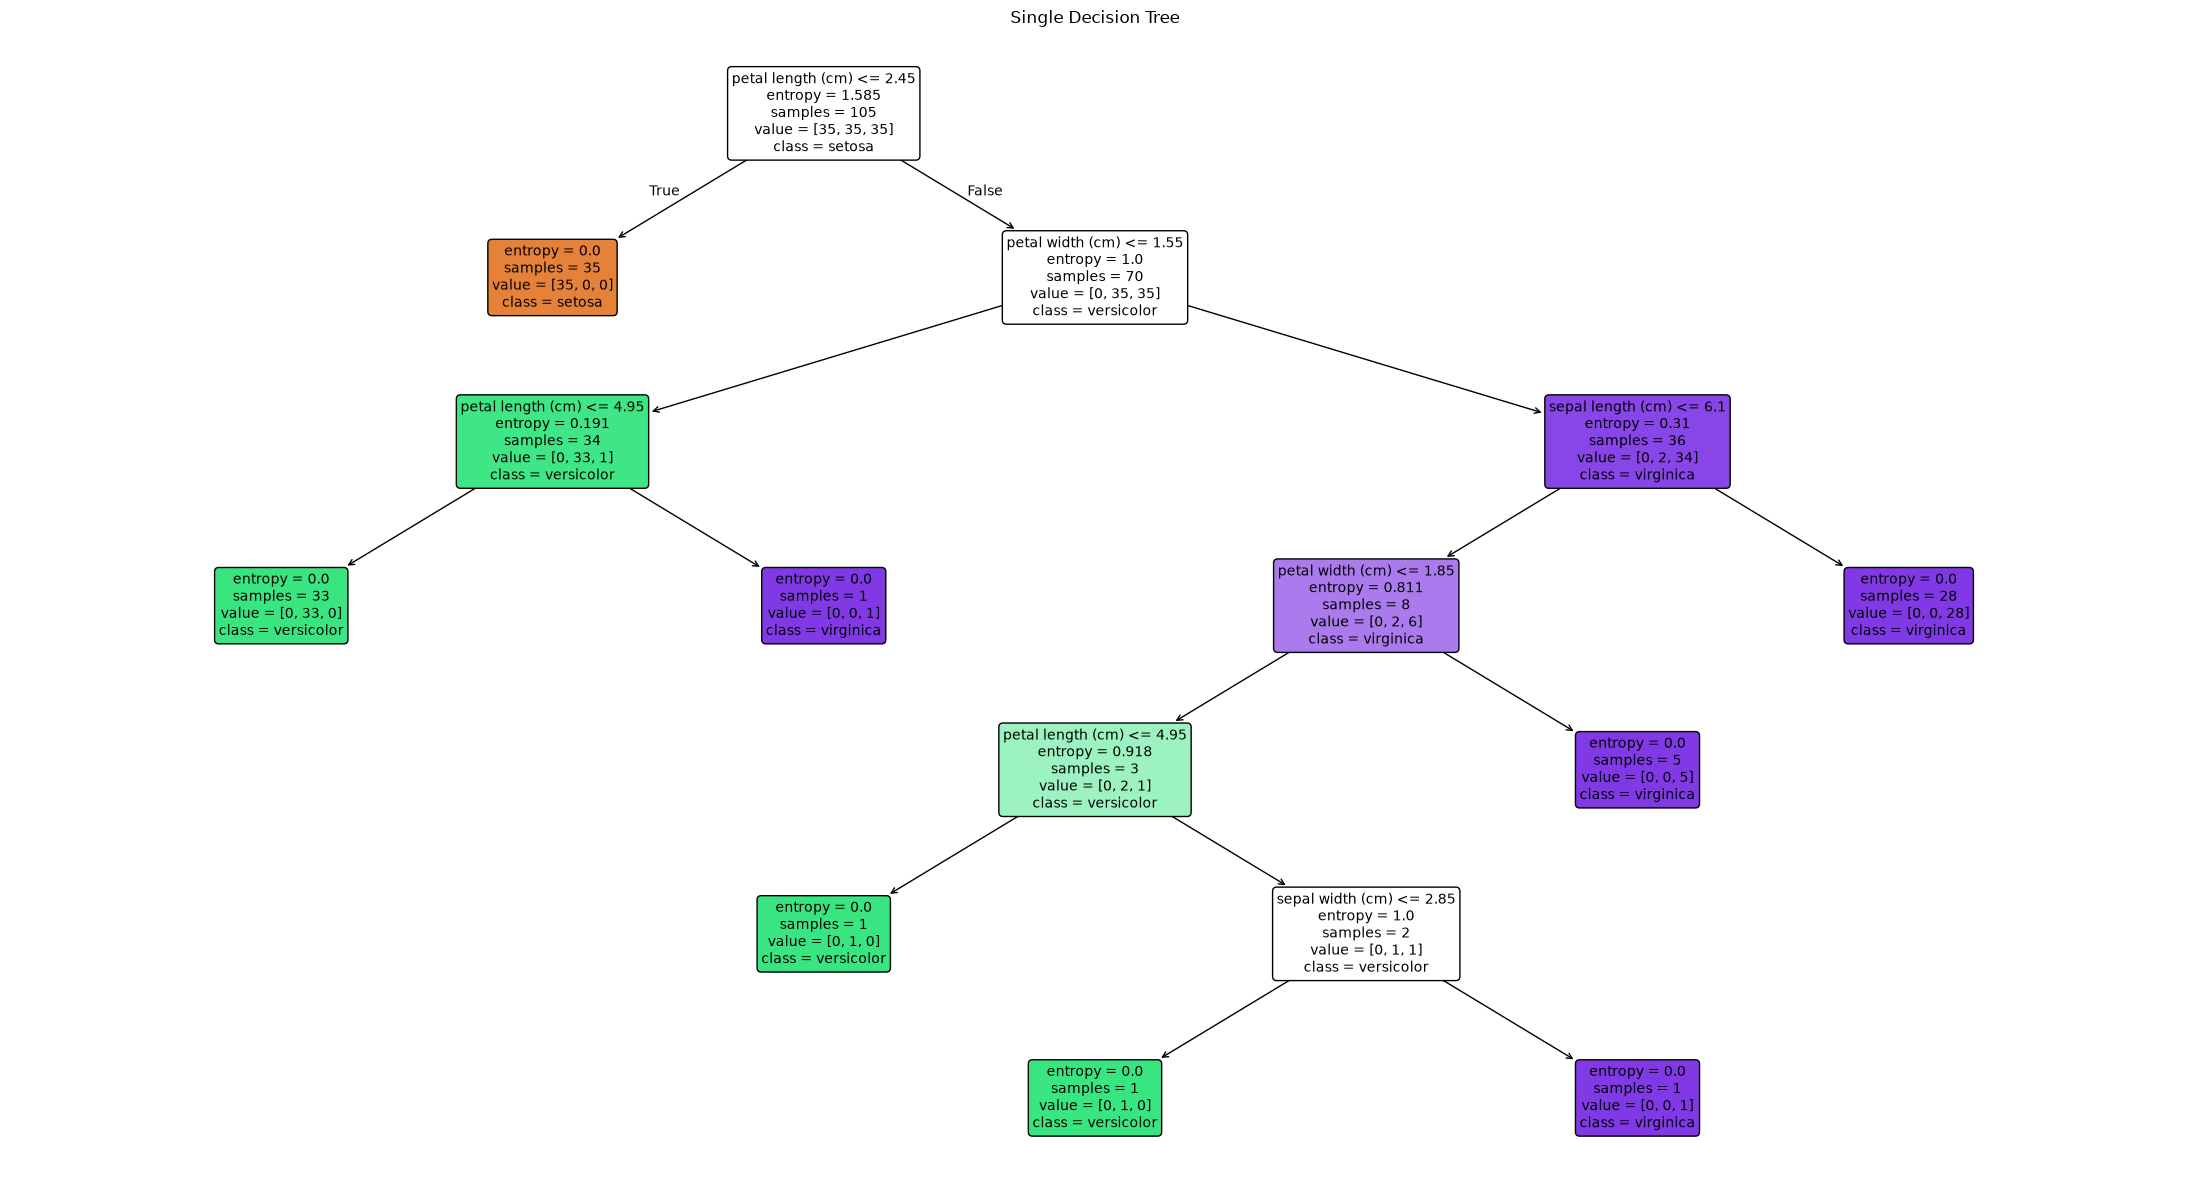

In [17]:
# ============================================================
# VISUALIZE SINGLE DECISION TREE
# ============================================================

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(22, 12))

plot_tree(
    dt_baseline,
    feature_names=X.columns,
    class_names=["setosa", "versicolor", "virginica"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Single Decision Tree")
plt.tight_layout()
plt.show()

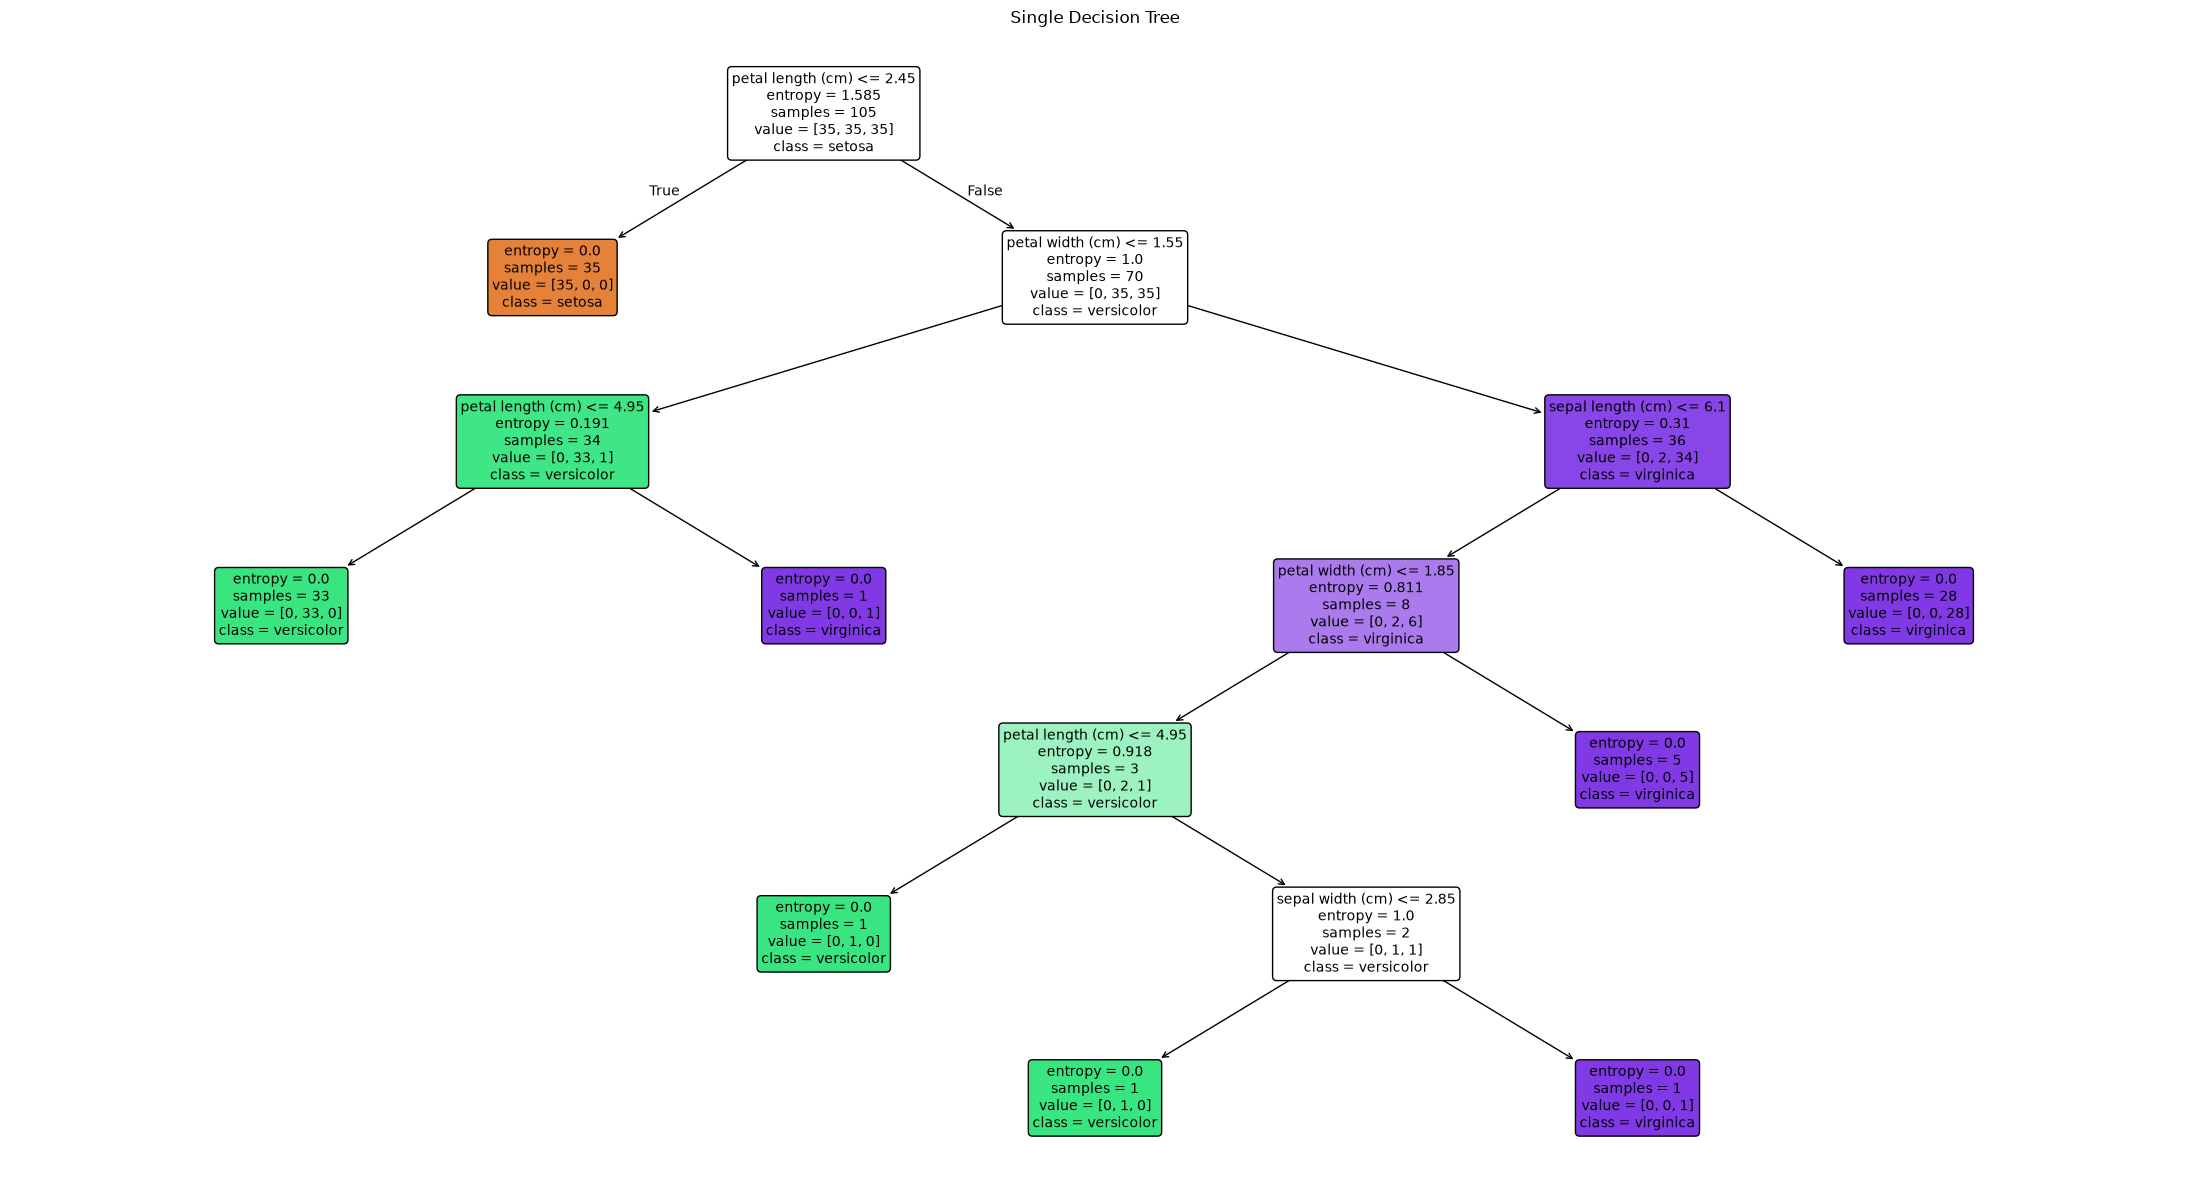

In [18]:
# ============================================================
# VISUALIZE SINGLE DECISION TREE
# ============================================================

plt.figure(figsize=(22, 12))

plot_tree(
    dt_baseline,
    feature_names=X.columns,
    class_names=["setosa", "versicolor", "virginica"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Single Decision Tree")

plt.tight_layout()

plt.show()

In [19]:
# ============================================================
# 9. RANDOM FOREST CLASSIFICATION REPORT
# ============================================================

print(classification_report(
    y_val,
    rf_val_pred,
    target_names=["setosa", "versicolor", "virginica"],
    zero_division=0
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45



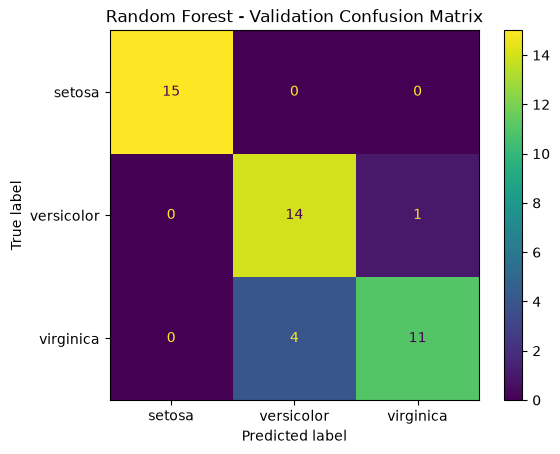

In [20]:
# ============================================================
# 10. RANDOM FOREST CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_val, rf_val_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["setosa", "versicolor", "virginica"]
).plot()

plt.title("Random Forest - Validation Confusion Matrix")

plt.show()

# Part C — OOB Error Convergence

For each tree, some training observations are not selected in its bootstrap sample. These are **Out-of-Bag (OOB)** observations for that tree.

As more trees are added, the OOB estimate usually becomes more stable.

We record OOB accuracy and OOB error for different numbers of trees.


In [16]:
# ============================================================
# 11. OOB ERROR CONVERGENCE
# ============================================================

n_estimators_values = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]

oob_results = []

for n in n_estimators_values:

    model = RandomForestClassifier(
        n_estimators=n,
        criterion="entropy",
        max_features="sqrt",
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    oob_acc = model.oob_score_

    oob_results.append({
        "n_estimators": n,
        "OOB_acc": oob_acc,
        "OOB_error": 1 - oob_acc
    })

oob_df = pd.DataFrame(oob_results)

display(oob_df.round(4))


c:\KLH\2026-2027\Subjects\Y25-ML\practical\Placement-Prediction-System\.MLvenv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\KLH\2026-2027\Subjects\Y25-ML\practical\Placement-Prediction-System\.MLvenv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,n_estimators,OOB_acc,OOB_error
0,1,0.4444,0.5556
1,5,0.4444,0.5556
2,10,0.5556,0.4444
3,20,0.5556,0.4444
4,30,0.5556,0.4444
5,50,0.5556,0.4444
6,75,0.5556,0.4444
7,100,0.5556,0.4444
8,150,0.5556,0.4444
9,200,0.5556,0.4444


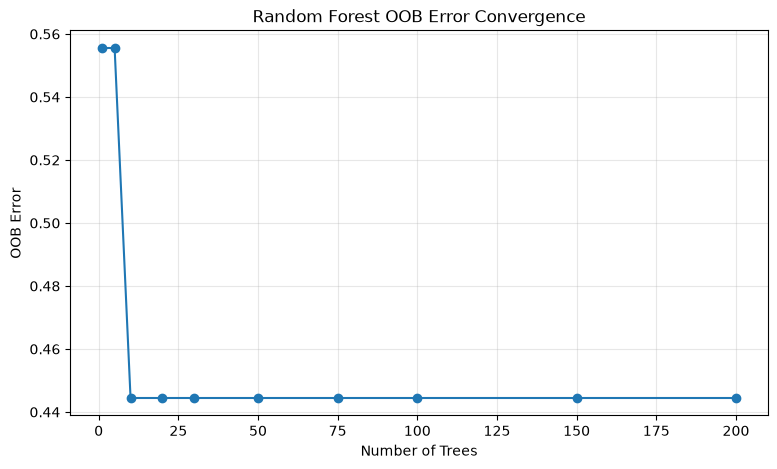

In [17]:
# ============================================================
# 12. PLOT OOB ERROR CONVERGENCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    oob_df["n_estimators"],
    oob_df["OOB_error"],
    marker="o"
)

plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.title("Random Forest OOB Error Convergence")
plt.grid(True, alpha=0.3)
plt.show()


### Student observation
Look for the region where OOB error becomes relatively stable.

With only 14 students, the OOB curve may jump around considerably. That is a limitation of the very small teaching dataset, not an error in the code.


# Part D — `max_features` Comparison

`max_features` controls how many features are considered when a tree searches for a split.

We compare:

- `sqrt`
- `log2`
- `None` → all features

This demonstrates **feature subsampling**.


In [18]:
# ============================================================
# 13. COMPARE max_features
# ============================================================

max_features_values = ["sqrt", "log2", None]
max_features_results = []

for mf in max_features_values:

    model = RandomForestClassifier(
        n_estimators=100,
        criterion="entropy",
        max_features=mf,
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    max_features_results.append({
        "max_features": str(mf),
        "Train_Accuracy": accuracy_score(y_train, train_pred),
        "Validation_Accuracy": accuracy_score(y_val, val_pred),
        "OOB_Accuracy": model.oob_score_,
        "OOB_Error": 1 - model.oob_score_
    })

max_features_df = pd.DataFrame(max_features_results)

display(max_features_df.round(4))


,max_features,Train_Accuracy,Validation_Accuracy,OOB_Accuracy,OOB_Error
0,sqrt,1.0,0.8,0.5556,0.4444
1,log2,1.0,0.8,0.5556,0.4444
2,None,1.0,0.6,0.5556,0.4444


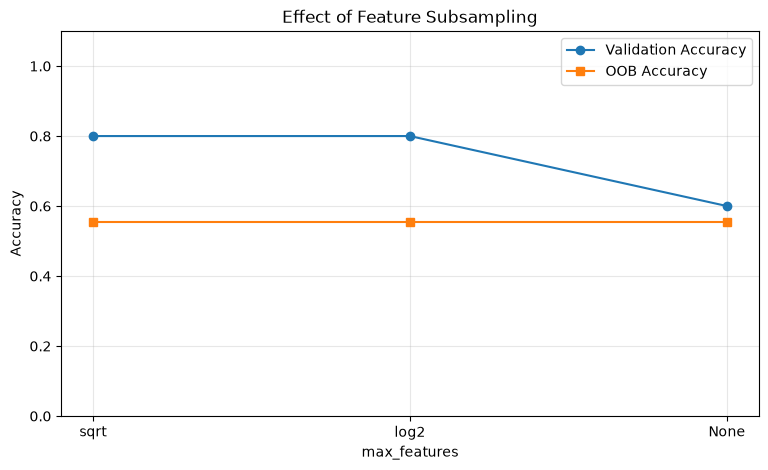

In [19]:
# ============================================================
# 14. PLOT max_features COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    max_features_df["max_features"],
    max_features_df["Validation_Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.plot(
    max_features_df["max_features"],
    max_features_df["OOB_Accuracy"],
    marker="s",
    label="OOB Accuracy"
)

plt.xlabel("max_features")
plt.ylabel("Accuracy")
plt.title("Effect of Feature Subsampling")
plt.legend()
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.show()


# Part E — Manual Bootstrap Bagging

### Layman idea

Suppose the training set has students:

`S1, S2, S3, S4, ...`

For one tree we randomly select students **with replacement**.

A bootstrap sample might look like:

`S1, S3, S3, S5, S7, S1, ...`

Another tree receives a different sample.

This section manually demonstrates the idea before using scikit-learn's BaggingClassifier.


In [20]:
# ============================================================
# 15. MANUAL BOOTSTRAP SAMPLE
# ============================================================

rng = np.random.default_rng(42)

indices = rng.choice(
    np.arange(len(X_train)),
    size=len(X_train),
    replace=True
)

oob_indices = np.setdiff1d(
    np.arange(len(X_train)),
    np.unique(indices)
)

print("Bootstrap indices:")
print(indices)

print("\nUnique selected rows:")
print(np.unique(indices))

print("\nOOB row indices:")
print(oob_indices)

print("\nTotal bootstrap observations:", len(indices))
print("Unique observations:", len(np.unique(indices)))
print("OOB observations:", len(oob_indices))


Bootstrap indices:
[0 6 5 3 3 7 0 6 1]

Unique selected rows:
[0 1 3 5 6 7]

OOB row indices:
[2 4 8]

Total bootstrap observations: 9
Unique observations: 6
OOB observations: 3


In [21]:
# ============================================================
# 16. MANUAL BAGGING: TRAIN MANY BOOTSTRAPPED TREES
# ============================================================

N_MANUAL_TREES = 50

manual_trees = []
rng = np.random.default_rng(42)

for tree_number in range(N_MANUAL_TREES):

    # Draw a bootstrap sample from training rows.
    sample_indices = rng.choice(
        np.arange(len(X_train)),
        size=len(X_train),
        replace=True
    )

    X_boot = X_train.iloc[sample_indices]
    y_boot = y_train.iloc[sample_indices]

    tree = DecisionTreeClassifier(
        criterion="entropy",
        random_state=tree_number
    )

    tree.fit(X_boot, y_boot)
    manual_trees.append(tree)

print(f"{N_MANUAL_TREES} manually bagged trees trained.")


50 manually bagged trees trained.


In [22]:
# ============================================================
# 17. MANUAL BAGGING: MAJORITY VOTE
# ============================================================

# Each tree predicts the validation students.
tree_predictions = np.array([
    tree.predict(X_val)
    for tree in manual_trees
])

# Majority vote across all trees.
manual_bagging_pred = (
    np.mean(tree_predictions, axis=0) >= 0.5
).astype(int)

manual_bagging_acc = accuracy_score(
    y_val,
    manual_bagging_pred
)

print(
    "Manual Bootstrap Bagging Validation Accuracy:",
    f"{manual_bagging_acc:.4f}"
)


Manual Bootstrap Bagging Validation Accuracy: 0.6000


# Part F — scikit-learn BaggingClassifier

The previous cells showed the mechanism manually.

Now `BaggingClassifier` automates bootstrap sampling and combines the tree predictions.

**Bagging vs Random Forest:**
- Bagging mainly uses bootstrap samples.
- Random Forest additionally introduces random feature selection at splits.


In [23]:
# ============================================================
# 18. BAGGING CLASSIFIER
# ============================================================

# Compatible with newer scikit-learn versions.
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    ),
    n_estimators=100,
    max_samples=1.0,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagging.fit(X_train, y_train)

bagging_train_pred = bagging.predict(X_train)
bagging_val_pred = bagging.predict(X_val)

print("BAGGING PERFORMANCE")
print("=" * 50)
print(f"Training Accuracy   : {accuracy_score(y_train, bagging_train_pred):.4f}")
print(f"Validation Accuracy : {accuracy_score(y_val, bagging_val_pred):.4f}")


c:\KLH\2026-2027\Subjects\Y25-ML\practical\Placement-Prediction-System\.MLvenv\Lib\site-packages\sklearn\ensemble\_bootstrap.py:64: UserWarning: Using the fractional value max_samples=1.0 when the number of samples is 9 results in a low number (9) of bootstrap samples. We recommend passing `max_samples` as an integer instead.
  warn(


BAGGING PERFORMANCE
Training Accuracy   : 1.0000
Validation Accuracy : 0.6000


# Part G — Permutation Importance

### Layman idea

1. Measure normal validation accuracy.
2. Shuffle one feature.
3. Predict again.
4. If accuracy drops a lot, that feature was important.
5. If accuracy changes little, that feature contributed less.

We calculate it on the validation set.


In [24]:
# ============================================================
# 19. PERMUTATION IMPORTANCE
# ============================================================

perm = permutation_importance(
    rf,
    X_val,
    y_val,
    n_repeats=30,
    random_state=42,
    scoring="accuracy"
)

importance_df = pd.DataFrame({
    "Feature": X_val.columns,
    "Mean_Importance": perm.importances_mean,
    "Std_Importance": perm.importances_std
}).sort_values(
    "Mean_Importance",
    ascending=False
).reset_index(drop=True)

display(importance_df.round(4))


,Feature,Mean_Importance,Std_Importance
0,Internships,0.2200,0.1194
1,CGPA,0.1333,0.0943
2,Aptitude,0.0467,0.0846
3,Backlogs,0.0000,0.0000


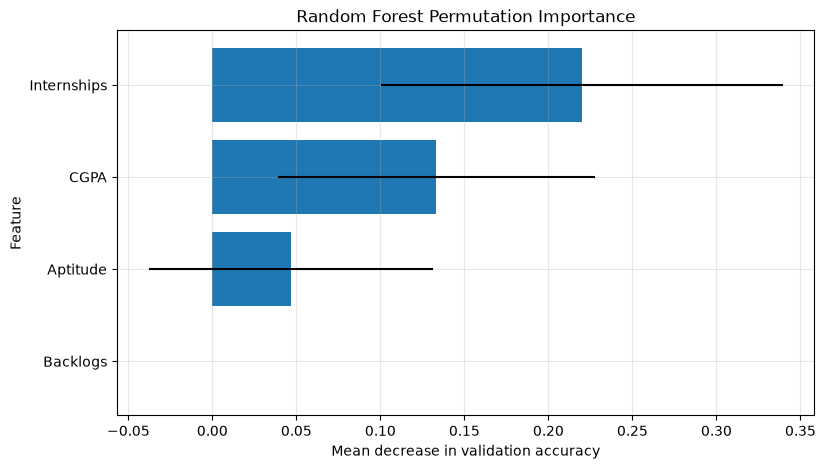

In [25]:
# ============================================================
# 20. PLOT PERMUTATION IMPORTANCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.barh(
    importance_df["Feature"],
    importance_df["Mean_Importance"],
    xerr=importance_df["Std_Importance"]
)

plt.xlabel("Mean decrease in validation accuracy")
plt.ylabel("Feature")
plt.title("Random Forest Permutation Importance")
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.show()


# Part H — `rf_vs_single_tree()` Function

This is the main reusable experiment.

The function receives:

`X_train, y_train, X_val, y_val, n_estimators_list`

and returns:

`[n_estimators, RF_val_acc, DT_val_acc, OOB_acc]`

It also plots the requested **three lines**.


In [26]:
# ============================================================
# 21. rf_vs_single_tree() FUNCTION
# ============================================================

def rf_vs_single_tree(
    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators_list
):
    """Compare Random Forest with one Decision Tree.

    Returns:
        DataFrame with columns:
        n_estimators, RF_val_acc, DT_val_acc, OOB_acc

    Also plots three lines:
        1. Random Forest validation accuracy
        2. Single Decision Tree validation accuracy
        3. Random Forest OOB accuracy
    """

    results = []

    # --------------------------------------------------------
    # Train one fixed Decision Tree baseline.
    # --------------------------------------------------------
    dt = DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    )

    dt.fit(X_train, y_train)

    dt_val_acc = accuracy_score(
        y_val,
        dt.predict(X_val)
    )

    # --------------------------------------------------------
    # Train Random Forests with different numbers of trees.
    # --------------------------------------------------------
    for n in n_estimators_list:

        rf_model = RandomForestClassifier(
            n_estimators=n,
            criterion="entropy",
            max_features="sqrt",
            bootstrap=True,
            oob_score=True,
            random_state=42,
            n_jobs=-1
        )

        rf_model.fit(X_train, y_train)

        rf_val_acc = accuracy_score(
            y_val,
            rf_model.predict(X_val)
        )

        oob_acc = rf_model.oob_score_

        results.append({
            "n_estimators": n,
            "RF_val_acc": rf_val_acc,
            "DT_val_acc": dt_val_acc,
            "OOB_acc": oob_acc
        })

    results_df = pd.DataFrame(results)

    # --------------------------------------------------------
    # Plot the three requested lines.
    # --------------------------------------------------------
    plt.figure(figsize=(10, 6))

    plt.plot(
        results_df["n_estimators"],
        results_df["RF_val_acc"],
        marker="o",
        label="Random Forest Validation Accuracy"
    )

    plt.plot(
        results_df["n_estimators"],
        results_df["DT_val_acc"],
        marker="s",
        label="Single Decision Tree Validation Accuracy"
    )

    plt.plot(
        results_df["n_estimators"],
        results_df["OOB_acc"],
        marker="^",
        label="Random Forest OOB Accuracy"
    )

    plt.xlabel("Number of Trees (n_estimators)")
    plt.ylabel("Accuracy")
    plt.title("Random Forest vs Single Decision Tree")
    plt.legend()
    plt.ylim(0, 1.1)
    plt.grid(True, alpha=0.3)
    plt.show()

    return results_df


c:\KLH\2026-2027\Subjects\Y25-ML\practical\Placement-Prediction-System\.MLvenv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\KLH\2026-2027\Subjects\Y25-ML\practical\Placement-Prediction-System\.MLvenv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


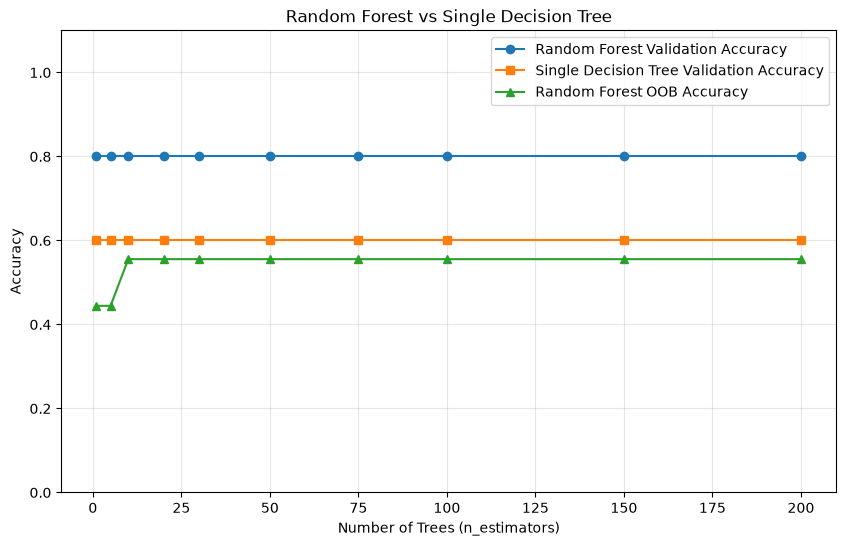

,n_estimators,RF_val_acc,DT_val_acc,OOB_acc
0,1,0.8,0.6,0.4444
1,5,0.8,0.6,0.4444
2,10,0.8,0.6,0.5556
3,20,0.8,0.6,0.5556
4,30,0.8,0.6,0.5556
5,50,0.8,0.6,0.5556
6,75,0.8,0.6,0.5556
7,100,0.8,0.6,0.5556
8,150,0.8,0.6,0.5556
9,200,0.8,0.6,0.5556


In [27]:
# ============================================================
# 22. RUN THE FUNCTION
# ============================================================

n_estimators_list = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]

rf_dt_results = rf_vs_single_tree(
    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators_list
)

display(rf_dt_results.round(4))


In [28]:
# ============================================================
# 23. BEST RANDOM FOREST SIZE
# ============================================================

best_rf_row = rf_dt_results.loc[
    rf_dt_results["RF_val_acc"].idxmax()
]

print("Best Random Forest result based on validation accuracy:")
print("=" * 65)
print(best_rf_row.to_string())


Best Random Forest result based on validation accuracy:
n_estimators    1.000000
RF_val_acc      0.800000
DT_val_acc      0.600000
OOB_acc         0.444444


# Part I — Overall Model Comparison

In [29]:
# ============================================================
# 24. OVERALL COMPARISON
# ============================================================

overall_comparison = pd.DataFrame({
    "Model": [
        "Single Decision Tree",
        "Random Forest",
        "Manual Bootstrap Bagging",
        "BaggingClassifier"
    ],
    "Training Accuracy": [
        accuracy_score(y_train, dt_train_pred),
        accuracy_score(y_train, rf_train_pred),
        np.nan,
        accuracy_score(y_train, bagging_train_pred)
    ],
    "Validation Accuracy": [
        accuracy_score(y_val, dt_val_pred),
        accuracy_score(y_val, rf_val_pred),
        manual_bagging_acc,
        accuracy_score(y_val, bagging_val_pred)
    ],
    "OOB Accuracy": [
        np.nan,
        rf.oob_score_,
        np.nan,
        np.nan
    ]
})

display(overall_comparison.round(4))


,Model,Training Accuracy,Validation Accuracy,OOB Accuracy
0,Single Decision Tree,1.0,0.6,NaN
1,Random Forest,1.0,0.8,0.5556
2,Manual Bootstrap Bagging,NaN,0.6,NaN
3,BaggingClassifier,1.0,0.6,NaN


# Final Learning Summary

Students should be able to explain:

1. How Random Forest combines many Decision Trees.
2. How bootstrap sampling creates different training sets.
3. What OOB observations are.
4. How OOB error changes as the number of trees increases.
5. What `max_features` means.
6. Why feature subsampling makes trees different.
7. How manual bagging works.
8. How permutation importance identifies influential features.
9. Whether Random Forest improves over a single Decision Tree on the validation data.
10. Why results from only 14 students should be interpreted as a classroom demonstration rather than a reliable real-world performance estimate.
